In [17]:
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import numpy as np
import statistics as st
import pandas as pd
import seaborn as sns
import math
import random

data = pd.read_csv('nba_second_round_history.csv')
data

,Season,Team,Opponent,Games played,Average Points scored,Average Points allowed,Offensive Rating,Defensive Rating,eFG%,Opp eFG%,TOV%,Opp TOV%,ORB%,Opp ORB%,FT/FGA,Opp FT/FGA,Champion
0,1984,BOS,NYK,7,111.0,103.0,113.9,105.7,0.498,0.484,14.2,16.0,38.7,35.0,0.285,0.296,True
1,1984,MIL,NJN,6,98.2,96.3,102.8,100.9,0.471,0.405,18.3,12.2,32.6,35.5,0.373,0.340,False
2,1984,LAL,DAL,5,120.6,106.2,121.9,107.4,0.570,0.454,12.8,11.9,37.8,35.1,0.200,0.232,False
3,1984,PHO,UTA,6,103.7,101.0,107.0,104.3,0.462,0.468,12.9,15.3,33.9,32.4,0.230,0.300,False
4,1985,BOS,DET,6,120.5,112.7,118.1,110.4,0.519,0.478,13.6,11.4,37.1,35.7,0.302,0.196,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,2025,MIN,GSW,5,109.0,101.8,113.9,106.4,0.567,0.494,16.8,15.4,26.2,32.0,0.189,0.227,False
168,2026,NYK,PHI,4,124.3,102.0,132.3,108.6,0.636,0.514,12.6,13.7,32.1,21.6,0.233,0.255,False
169,2026,CLE,DET,7,108.9,107.4,115.6,114.1,0.537,0.525,14.6,14.0,29.4,32.3,0.299,0.203,False
170,2026,SAS,MIN,6,120.7,104.5,119.0,103.1,0.565,0.464,12.5,12.0,26.9,24.0,0.250,0.191,False


Data Augmentation

In [ ]:
# 1. Add Net Rating column
data['Net Rating'] = (data['Offensive Rating'] - data['Defensive Rating']).round(3)

# 2. Add Average Points Difference column
data['Average Points Difference'] = (data['Average Points scored'] - data['Average Points allowed']).round(3)

# 3. Add eFG% Difference column
data['eFG% Difference'] = (data['eFG%'] - data['Opp eFG%']).round(3)

# 4. Add TOV% Difference column
data['TOV% Difference'] = (data['TOV%'] - data['Opp TOV%']).round(3)

# 5. Add ORB% Difference column
data['ORB% Difference'] = (data['ORB%'] - data['Opp ORB%']).round(3)

# 6. Add FT/FGA Difference column
data['FT/FGA Difference'] = (data['FT/FGA'] - data['Opp FT/FGA']).round(3)

# 7. Add Actual Wins column
data['Actual Wins (%)'] = (4 / data['Games played'] * 100).round(3)

# 8. Add Pythagorean Wins column (a measure of dominance)(https://gemini.google.com/share/081f957375cf)
data['Pythagorean Wins (13.91) (%)'] = ((data['Average Points scored'] ** 13.91) / ((data['Average Points scored'] ** 13.91) + (data['Average Points allowed'] ** 13.91)) * 100).round(3)
data['Pythagorean Wins (16.5) (%)'] = ((data['Average Points scored'] ** 16.5) / ((data['Average Points scored'] ** 16.5) + (data['Average Points allowed'] ** 16.5)) * 100).round(3)

# Save the modified dataset to a new CSV file
data.to_csv('nba_second_round_history_modified.csv', index=False)

Pythagorean Wins Statistics & Plot

In [30]:
print(data['Pythagorean Wins (13.91) (%)'].describe())
print('\n')
print(data['Pythagorean Wins (16.5) (%)'].describe())

count    172.000000
mean      66.833547
std       12.922692
min       40.106000
25%       56.366250
50%       66.632000
75%       76.443000
max       97.681000
Name: Pythagorean Wins (13.91) (%), dtype: float64


count    172.000000
mean      69.095337
std       14.289863
min       38.327000
25%       57.534750
50%       69.431000
75%       80.159250
max       98.831000
Name: Pythagorean Wins (16.5) (%), dtype: float64


<Axes: xlabel='Pythagorean Wins (13.91) (%)', ylabel='Count'>

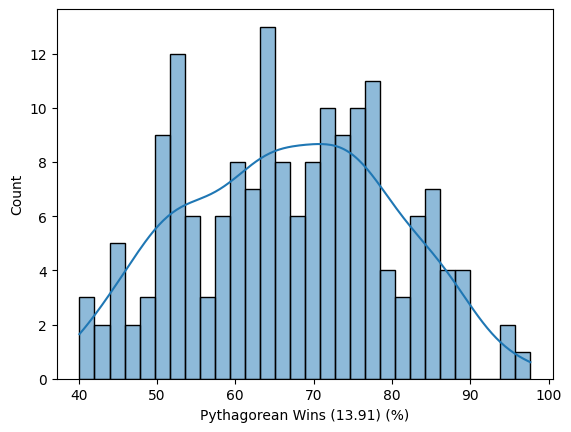

In [35]:
sns.histplot(data['Pythagorean Wins (13.91) (%)'], bins=30, kde=True)

In [ ]:
sns.histplot(data['Pythagorean Wins (16.5) (%)'], bins=30, kde=True)

Relation between the two metrics

<Axes: xlabel='Games played', ylabel='Pythagorean Wins (13.91) (%)'>

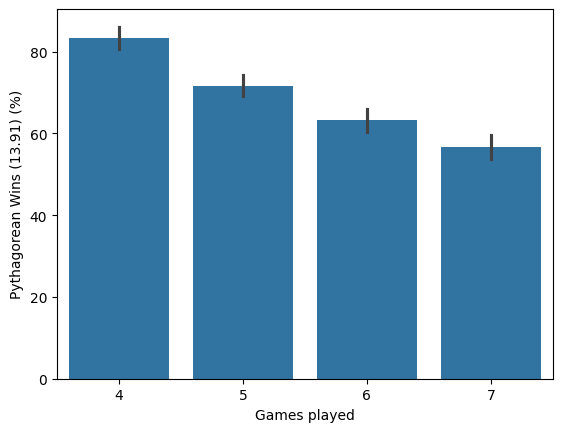

In [37]:
sns.barplot(data=data, x='Games played', y='Pythagorean Wins (13.91) (%)')

<Axes: xlabel='Games played', ylabel='Pythagorean Wins (16.5) (%)'>

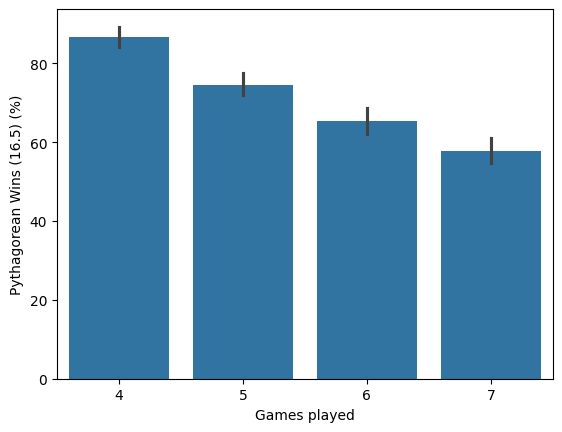

In [38]:
sns.barplot(data=data, x='Games played', y='Pythagorean Wins (16.5) (%)')

<Axes: xlabel='Games played', ylabel='Pythagorean Wins (13.91) (%)'>

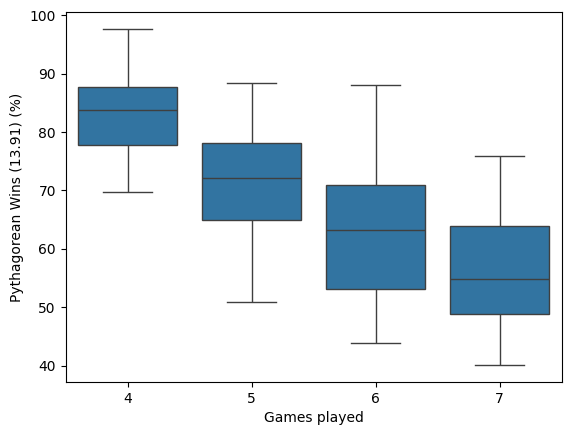

In [41]:
sns.boxplot(data=data, y='Pythagorean Wins (13.91) (%)', x='Games played')

Games Played Plot

   Games played  Count
0             7     47
1             6     49
2             5     52
3             4     24


<Axes: xlabel='Games played', ylabel='Count'>

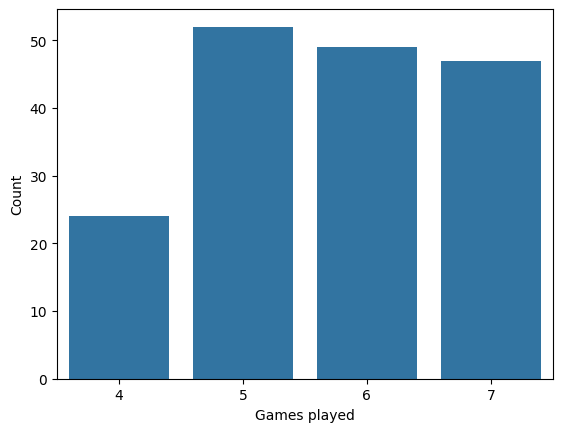

In [43]:
games_played = data['Games played'].value_counts(sort=False).reset_index(name='Count')
print(games_played)
sns.barplot(data=games_played, x='Games played', y='Count')